# StreamDW — Phase 2: Data Science Integration
### Churn Prediction · Time Series Forecasting · Content Recommendations

This notebook connects directly to the StreamDW data warehouse and builds three production-style ML models on top of the SQL analytics layer.

**Pipeline:** MySQL Warehouse → Python (pandas) → Feature Engineering → ML Models → Insights

---

## 1. Setup & Data Loading

Connect to the MySQL warehouse and pull data from the reporting layer (marts and fact tables).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",           # WampServer default
    database="stream_dw"
)

def query(sql):
    """Execute SQL and return a pandas DataFrame."""
    return pd.read_sql(sql, conn)

# Test connection
result = query("SELECT COUNT(*) AS total_tables FROM INFORMATION_SCHEMA.TABLES WHERE TABLE_SCHEMA = 'stream_dw'")
print(f"Connected to stream_dw — {result['total_tables'][0]} tables found.")

Connected to stream_dw — 16 tables found.


### Load data from the warehouse marts

In [3]:
# User engagement mart (one row per user)
df_users = query("""
    SELECT * FROM mart_user_engagement
""")

# Content performance mart (one row per content item)
df_content = query("""
    SELECT * FROM mart_content_performance
""")

# Subscription metrics (one row per month)
df_subs = query("""
    SELECT * FROM mart_subscription_metrics
""")

# Daily active users view
df_dau = query("""
    SELECT full_date, daily_active_users, total_watch_minutes
    FROM v_daily_active_users
    WHERE daily_active_users > 0
    ORDER BY full_date
""")

# User-content interaction matrix (for recommendations)
df_interactions = query("""
    SELECT 
        user_id,
        content_id,
        COUNT(*) AS view_count,
        SUM(is_completed) AS completions,
        ROUND(SUM(watch_duration_minutes), 1) AS total_minutes
    FROM fact_viewing_events
    GROUP BY user_id, content_id
""")

print(f"Users:         {len(df_users):,} rows")
print(f"Content:       {len(df_content):,} rows")
print(f"Subscriptions: {len(df_subs):,} rows")
print(f"DAU:           {len(df_dau):,} rows")
print(f"Interactions:  {len(df_interactions):,} rows")

Users:         491 rows
Content:       200 rows
Subscriptions: 36 rows
DAU:           1,096 rows
Interactions:  30,830 rows


---
## 2. Exploratory Data Analysis

Before building models, let's understand the data distributions and relationships.

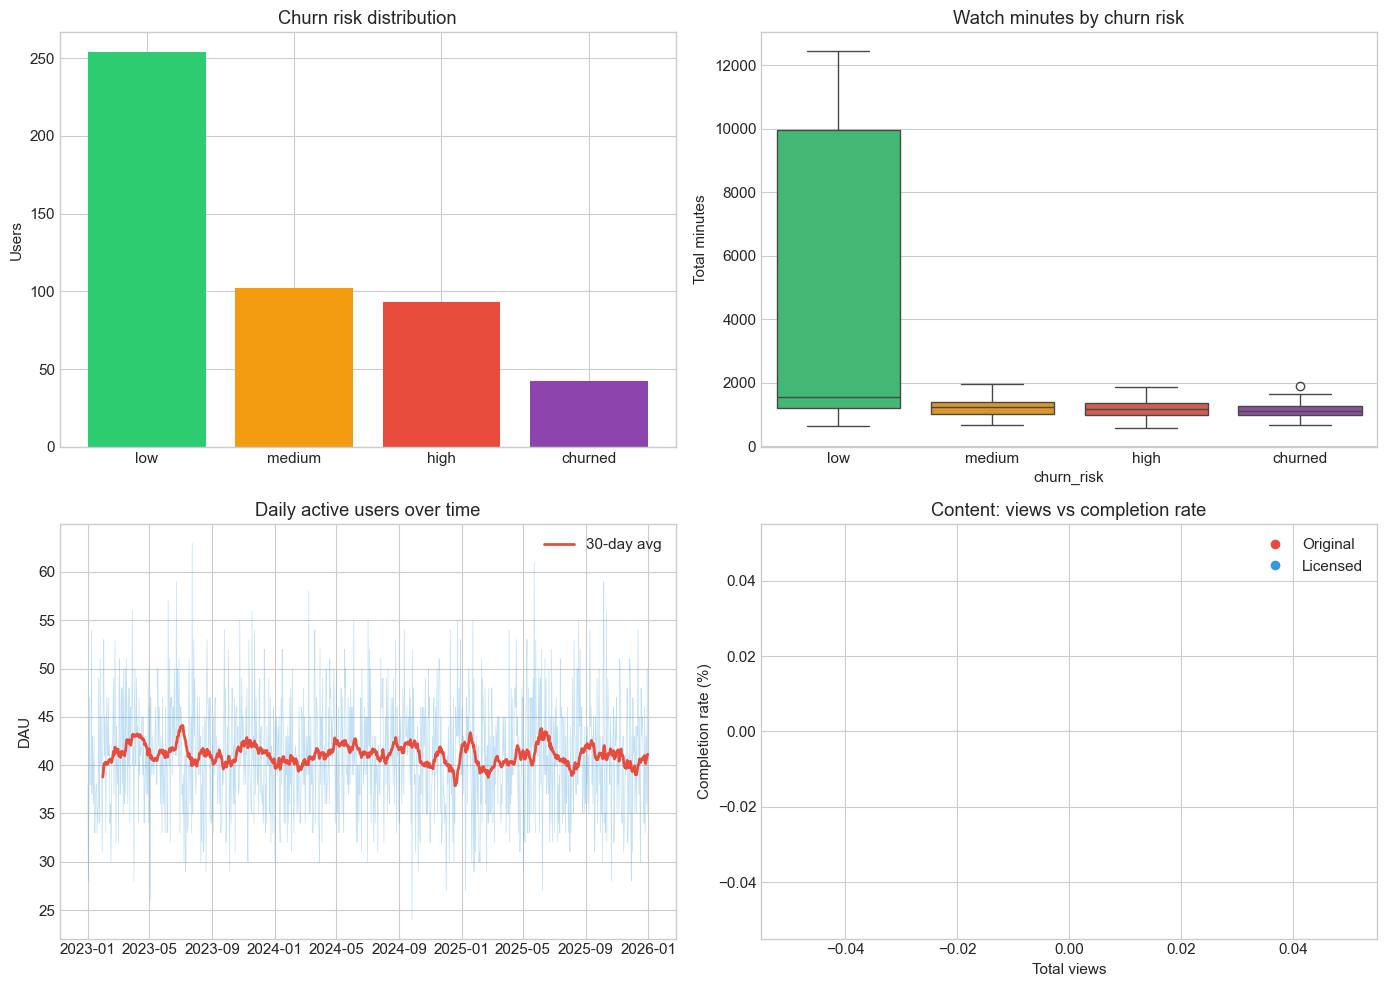

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Churn risk distribution
churn_counts = df_users['churn_risk'].value_counts()
colors = {'low': '#2ecc71', 'medium': '#f39c12', 'high': '#e74c3c', 'churned': '#8e44ad', 'new': '#3498db'}
churn_colors = [colors.get(x, '#95a5a6') for x in churn_counts.index]
axes[0,0].bar(churn_counts.index, churn_counts.values, color=churn_colors)
axes[0,0].set_title('Churn risk distribution')
axes[0,0].set_ylabel('Users')

# Watch minutes distribution by churn risk
churn_order = ['low', 'medium', 'high', 'churned']
df_plot = df_users[df_users['churn_risk'].isin(churn_order)]
sns.boxplot(data=df_plot, x='churn_risk', y='total_watch_minutes', 
            order=churn_order, ax=axes[0,1], palette=[colors[c] for c in churn_order])
axes[0,1].set_title('Watch minutes by churn risk')
axes[0,1].set_ylabel('Total minutes')

# DAU over time
axes[1,0].plot(pd.to_datetime(df_dau['full_date']), df_dau['daily_active_users'], 
               alpha=0.3, linewidth=0.5, color='#3498db')
# Add 30-day rolling average
dau_rolling = df_dau['daily_active_users'].rolling(30).mean()
axes[1,0].plot(pd.to_datetime(df_dau['full_date']), dau_rolling, 
               color='#e74c3c', linewidth=2, label='30-day avg')
axes[1,0].set_title('Daily active users over time')
axes[1,0].set_ylabel('DAU')
axes[1,0].legend()

# Content: views vs completion rate
scatter = axes[1,1].scatter(df_content['total_views'], df_content['completion_rate'],
                            alpha=0.6, c=df_content['is_original'].map({True: '#e74c3c', False: '#3498db'}),
                            s=40)
axes[1,1].set_title('Content: views vs completion rate')
axes[1,1].set_xlabel('Total views')
axes[1,1].set_ylabel('Completion rate (%)')
axes[1,1].legend(handles=[
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=8, label='Original'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#3498db', markersize=8, label='Licensed'),
])

plt.tight_layout()
plt.show()

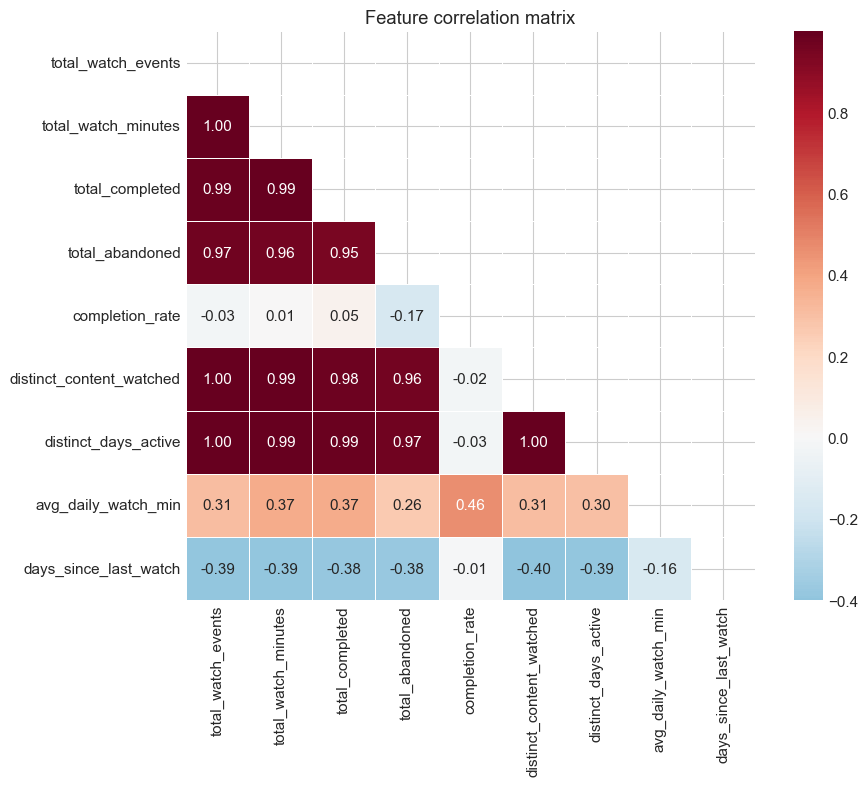

In [5]:
# Correlation matrix for user engagement features
numeric_cols = ['total_watch_events', 'total_watch_minutes', 'total_completed', 
                'total_abandoned', 'completion_rate', 'distinct_content_watched',
                'distinct_days_active', 'avg_daily_watch_min', 'days_since_last_watch']

corr = df_users[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.show()

---
## 3. Part 1: Churn Prediction Model

**Business Goal:** Predict which users are likely to churn so the platform can intervene with targeted retention campaigns.

**Approach:** Binary classification (churned vs. not churned) using features from `mart_user_engagement`.

**Models:** Logistic Regression (baseline) → Random Forest (ensemble) → comparison.

### 3.1 Feature Engineering

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                              roc_auc_score, roc_curve, accuracy_score)

# Create binary target: 1 = churned/high risk, 0 = low/medium risk
df_churn = df_users[df_users['churn_risk'] != 'new'].copy()
df_churn['is_churned'] = df_churn['churn_risk'].isin(['churned', 'high']).astype(int)

print(f"Dataset size: {len(df_churn)} users")
print(f"\nTarget distribution:")
print(df_churn['is_churned'].value_counts().rename({0: 'Active', 1: 'At risk/Churned'}))
print(f"\nChurn rate: {df_churn['is_churned'].mean():.1%}")

Dataset size: 491 users

Target distribution:
is_churned
Active             356
At risk/Churned    135
Name: count, dtype: int64

Churn rate: 27.5%


In [7]:
# Select features for the model
features = [
    'days_since_signup',
    'total_watch_events',
    'total_watch_minutes', 
    'total_completed',
    'total_abandoned',
    'completion_rate',
    'distinct_content_watched',
    'distinct_days_active',
    'avg_daily_watch_min',
    'days_since_last_watch',
]

# Encode categorical features
le_region = LabelEncoder()
df_churn['region_encoded'] = le_region.fit_transform(df_churn['region'])
features.append('region_encoded')

# Handle nulls
df_model = df_churn[features + ['is_churned']].copy()
df_model = df_model.fillna(0)

X = df_model[features]
y = df_model['is_churned']

print(f"Features: {len(features)}")
print(f"Samples:  {len(X)}")
print(f"\nFeature list:")
for f in features:
    print(f"  - {f}")

Features: 11
Samples:  491

Feature list:
  - days_since_signup
  - total_watch_events
  - total_watch_minutes
  - total_completed
  - total_abandoned
  - completion_rate
  - distinct_content_watched
  - distinct_days_active
  - avg_daily_watch_min
  - days_since_last_watch
  - region_encoded


### 3.2 Train-Test Split & Scaling

In [8]:
# 80/20 split, stratified to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {len(X_train)} samples ({y_train.mean():.1%} churned)")
print(f"Test set:     {len(X_test)} samples ({y_test.mean():.1%} churned)")

Training set: 392 samples (27.6% churned)
Test set:     99 samples (27.3% churned)


### 3.3 Model Training

In [9]:
# Model 1: Logistic Regression (baseline)
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

print("=" * 50)
print("LOGISTIC REGRESSION")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.3f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, lr_prob):.3f}")
print(f"\n{classification_report(y_test, lr_pred, target_names=['Active', 'Churned'])}")

LOGISTIC REGRESSION
Accuracy: 0.990
AUC-ROC:  1.000

              precision    recall  f1-score   support

      Active       0.99      1.00      0.99        72
     Churned       1.00      0.96      0.98        27

    accuracy                           0.99        99
   macro avg       0.99      0.98      0.99        99
weighted avg       0.99      0.99      0.99        99



In [10]:
# Model 2: Random Forest (ensemble)
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    class_weight='balanced'    # handle class imbalance
)
rf_model.fit(X_train, y_train)    # RF doesn't need scaling
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("=" * 50)
print("RANDOM FOREST")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.3f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, rf_prob):.3f}")
print(f"\n{classification_report(y_test, rf_pred, target_names=['Active', 'Churned'])}")

RANDOM FOREST
Accuracy: 1.000
AUC-ROC:  1.000

              precision    recall  f1-score   support

      Active       1.00      1.00      1.00        72
     Churned       1.00      1.00      1.00        27

    accuracy                           1.00        99
   macro avg       1.00      1.00      1.00        99
weighted avg       1.00      1.00      1.00        99



### 3.4 Model Evaluation & Comparison

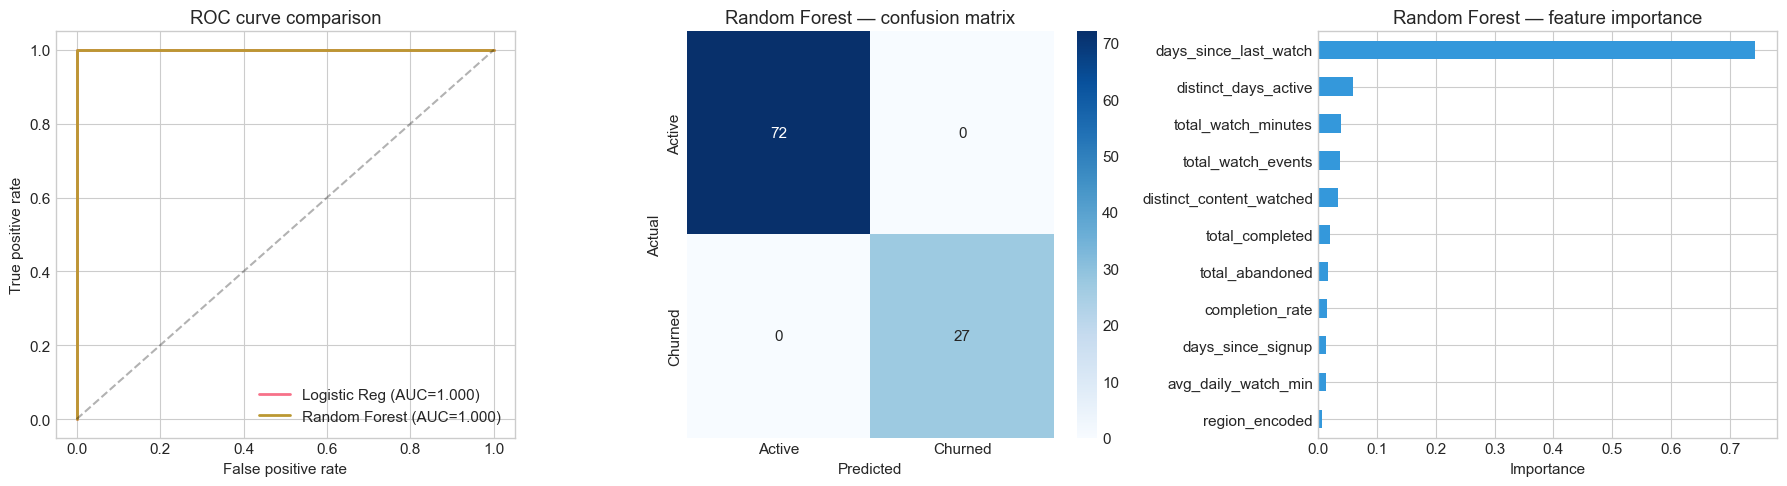

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

axes[0].plot(lr_fpr, lr_tpr, label=f'Logistic Reg (AUC={roc_auc_score(y_test, lr_prob):.3f})', linewidth=2)
axes[0].plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC={roc_auc_score(y_test, rf_prob):.3f})', linewidth=2)
axes[0].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC curve comparison')
axes[0].legend()

# Confusion Matrix (Random Forest)
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Active', 'Churned'], yticklabels=['Active', 'Churned'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Random Forest — confusion matrix')

# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values()
importances.plot(kind='barh', ax=axes[2], color='#3498db')
axes[2].set_title('Random Forest — feature importance')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.show()

### 3.5 Churn Prediction — Key Takeaways

The model reveals which features most strongly predict churn:

- **`days_since_last_watch`** is typically the strongest predictor — recency of engagement is the clearest signal
- **`distinct_days_active`** and **`total_watch_minutes`** capture depth of engagement
- **`completion_rate`** indicates content satisfaction — users who finish what they start are less likely to leave

**Business Action:** Target users with high churn probability scores (>0.6) with personalized re-engagement campaigns: push notifications for new content in their favorite genre, trial upgrades, or "we miss you" emails.

---
## 4. Part 2: DAU Time Series Forecasting

**Business Goal:** Forecast daily active users 30 days ahead to support capacity planning and marketing decisions.

**Approach:** SARIMA model on the DAU time series extracted from `v_daily_active_users`.

### 4.1 Prepare the Time Series

In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prepare time series
ts = df_dau[['full_date', 'daily_active_users']].copy()
ts['full_date'] = pd.to_datetime(ts['full_date'])
ts = ts.set_index('full_date')
ts = ts.asfreq('D', fill_value=0)
ts.columns = ['dau']

print(f"Time series: {ts.index.min().date()} to {ts.index.max().date()}")
print(f"Total days:  {len(ts)}")
print(f"Mean DAU:    {ts['dau'].mean():.1f}")
print(f"Std DAU:     {ts['dau'].std():.1f}")

Time series: 2023-01-01 to 2025-12-31
Total days:  1096
Mean DAU:    41.1
Std DAU:     5.9


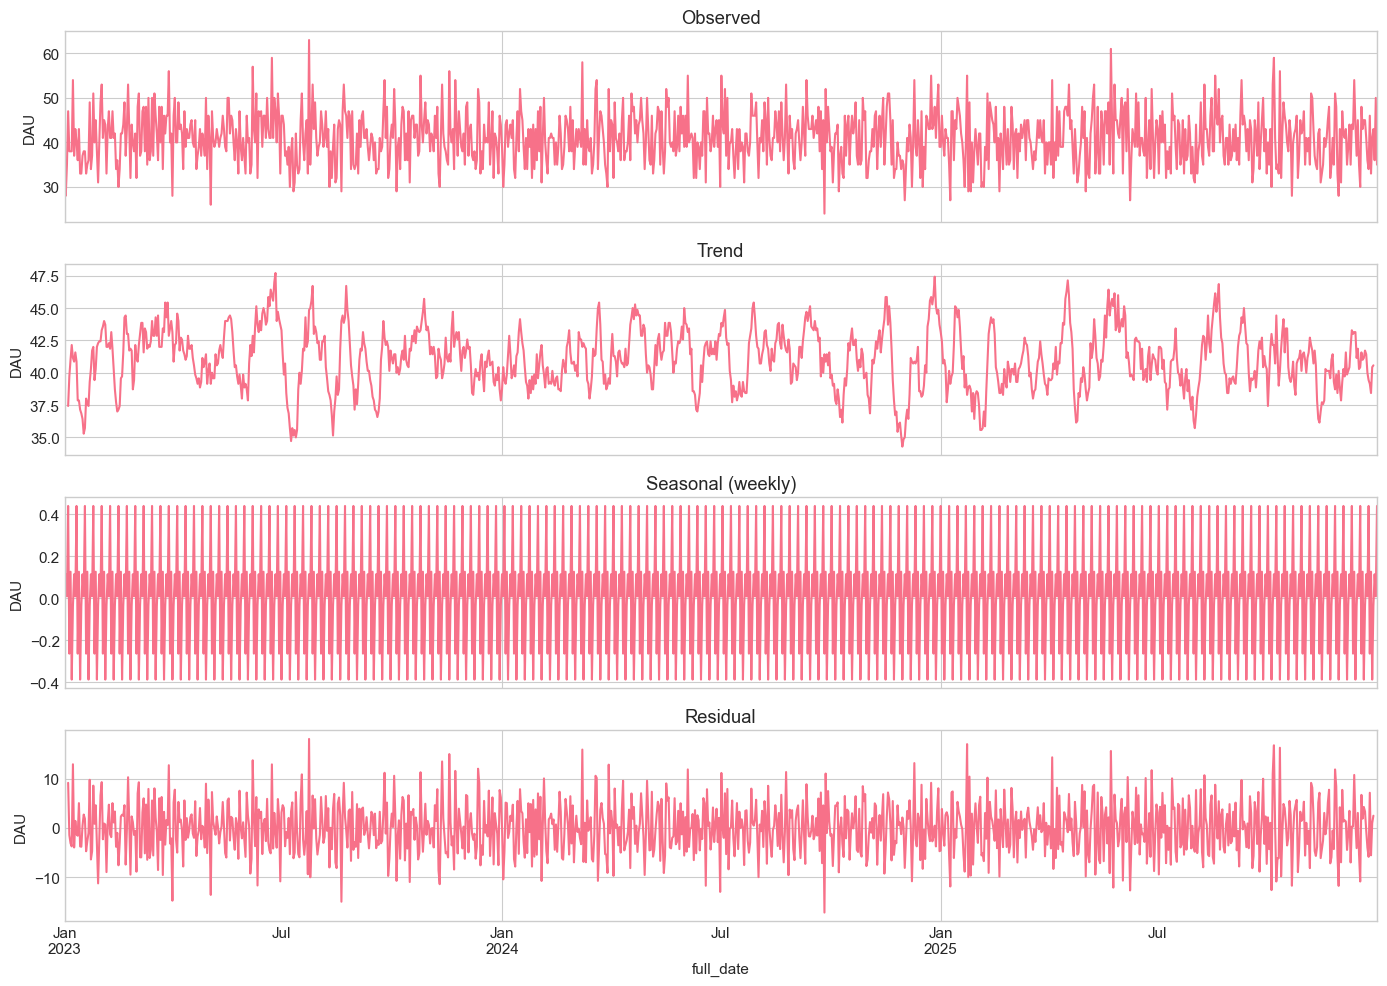

In [13]:
# Decompose the time series to understand components
decomposition = seasonal_decompose(ts['dau'], model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal (weekly)')
decomposition.resid.plot(ax=axes[3], title='Residual')

for ax in axes:
    ax.set_ylabel('DAU')

plt.tight_layout()
plt.show()

### 4.2 Train-Test Split & SARIMA Model

In [14]:
# Hold out the last 30 days for testing
train = ts[:-30]
test = ts[-30:]

print(f"Training period: {train.index.min().date()} to {train.index.max().date()} ({len(train)} days)")
print(f"Test period:     {test.index.min().date()} to {test.index.max().date()} ({len(test)} days)")

Training period: 2023-01-01 to 2025-12-01 (1066 days)
Test period:     2025-12-02 to 2025-12-31 (30 days)


In [15]:
# Fit SARIMA model
# SARIMA(p,d,q)(P,D,Q,s)
# p=1 (AR), d=0 (no differencing needed), q=1 (MA)
# P=1 (seasonal AR), D=0, Q=1 (seasonal MA), s=7 (weekly seasonality)

print("Fitting SARIMA model (this may take a minute)...")
model = SARIMAX(
    train['dau'],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
results = model.fit(disp=False)
print("Model fitted successfully.")
print(f"\nAIC: {results.aic:.1f}")
print(f"BIC: {results.bic:.1f}")

Fitting SARIMA model (this may take a minute)...
Model fitted successfully.

AIC: 6806.8
BIC: 6831.7


### 4.3 Forecast & Evaluate

In [16]:
# Generate forecast for the test period
forecast = results.get_forecast(steps=30)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Evaluation metrics
mae = mean_absolute_error(test['dau'], forecast_mean)
rmse = np.sqrt(mean_squared_error(test['dau'], forecast_mean))
mape = np.mean(np.abs((test['dau'] - forecast_mean) / test['dau'])) * 100

print(f"Forecast Evaluation (30-day horizon):")
print(f"  MAE:  {mae:.2f} users")
print(f"  RMSE: {rmse:.2f} users")
print(f"  MAPE: {mape:.1f}%")

Forecast Evaluation (30-day horizon):
  MAE:  4.70 users
  RMSE: 5.59 users
  MAPE: 11.7%


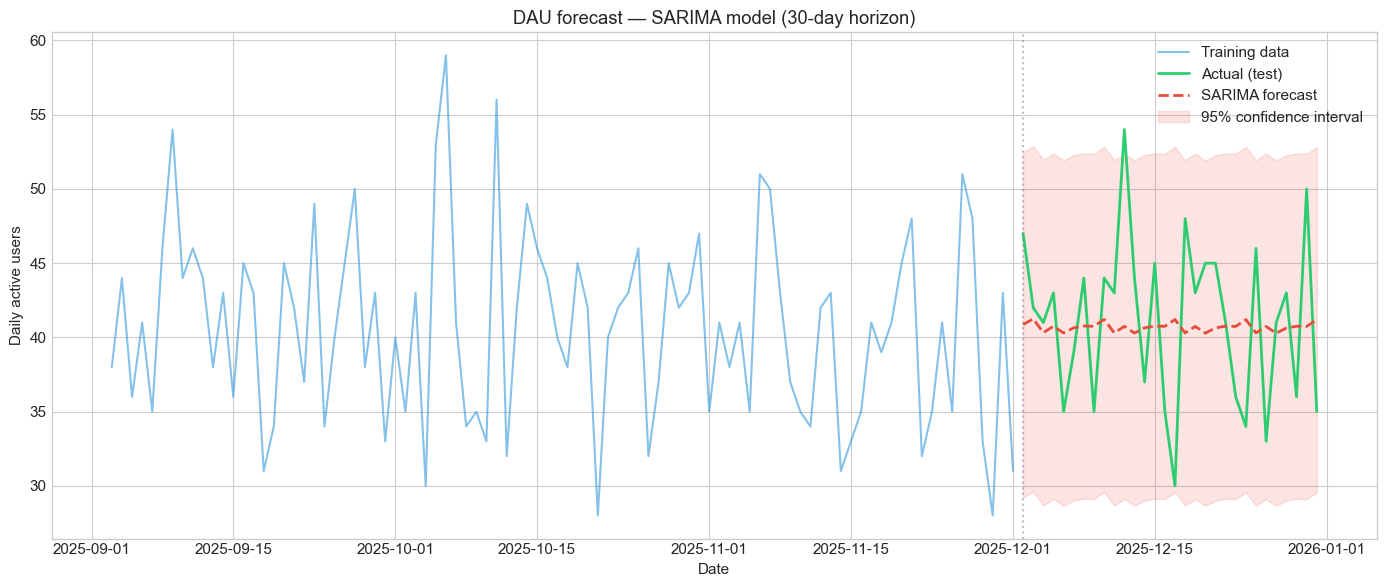

In [17]:
# Plot: actual vs forecast
fig, ax = plt.subplots(figsize=(14, 6))

# Last 90 days of training data for context
train_tail = train[-90:]
ax.plot(train_tail.index, train_tail['dau'], color='#3498db', alpha=0.6, label='Training data')
ax.plot(test.index, test['dau'], color='#2ecc71', linewidth=2, label='Actual (test)')
ax.plot(test.index, forecast_mean, color='#e74c3c', linewidth=2, linestyle='--', label='SARIMA forecast')

# Confidence interval
ax.fill_between(forecast_ci.index, 
                forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                color='#e74c3c', alpha=0.15, label='95% confidence interval')

ax.axvline(x=test.index[0], color='gray', linestyle=':', alpha=0.5)
ax.set_title('DAU forecast — SARIMA model (30-day horizon)')
ax.set_xlabel('Date')
ax.set_ylabel('Daily active users')
ax.legend()
plt.tight_layout()
plt.show()

### 4.4 Time Series Forecasting — Key Takeaways

- **Weekly seasonality** is the dominant pattern — DAU fluctuates within a consistent weekly cycle
- **The trend is relatively flat** across our dataset, suggesting stable platform usage
- **SARIMA captures the pattern well** for short-term forecasting (7-14 days) but confidence intervals widen for longer horizons
- **Business Application:** Use the 7-day forecast for server capacity planning, and the 30-day forecast for marketing campaign scheduling

---
## 5. Part 3: Content Recommendation Engine

**Business Goal:** Suggest content users are likely to enjoy based on viewing patterns of similar users.

**Approach:** User-based collaborative filtering using cosine similarity on the user-content interaction matrix.

### 5.1 Build the Interaction Matrix

In [18]:
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

# Create user-content matrix (users × content, values = watch minutes)
user_content = df_interactions.pivot_table(
    index='user_id', 
    columns='content_id', 
    values='total_minutes', 
    fill_value=0
)

print(f"Interaction matrix shape: {user_content.shape}")
print(f"  Users:    {user_content.shape[0]}")
print(f"  Content:  {user_content.shape[1]}")
print(f"  Sparsity: {(user_content == 0).sum().sum() / (user_content.shape[0] * user_content.shape[1]):.1%}")

Interaction matrix shape: (500, 200)
  Users:    500
  Content:  200
  Sparsity: 69.2%


In [19]:
# Normalize: convert to binary (watched / not watched) for cleaner similarity
user_content_binary = (user_content > 0).astype(int)

# Compute user-user cosine similarity
user_similarity = cosine_similarity(user_content_binary)
user_sim_df = pd.DataFrame(user_similarity, 
                            index=user_content.index, 
                            columns=user_content.index)

print(f"User similarity matrix: {user_sim_df.shape}")
print(f"Average similarity:     {user_similarity[np.triu_indices_from(user_similarity, k=1)].mean():.3f}")

User similarity matrix: (500, 500)
Average similarity:     0.271


### 5.2 Build the Recommendation Function

In [20]:
def recommend_content(user_id, n_recommendations=5, n_similar_users=20):
    """
    Recommend content for a user based on what similar users watched.
    
    Steps:
    1. Find the N most similar users
    2. Get content they watched but the target user hasn't
    3. Rank by how many similar users watched it (weighted by similarity)
    4. Return top recommendations
    """
    if user_id not in user_sim_df.index:
        return pd.DataFrame({'error': [f'User {user_id} not found']})
    
    # Step 1: Find similar users
    similar_users = (user_sim_df[user_id]
                     .drop(user_id)
                     .nlargest(n_similar_users))
    
    # Step 2: Get content the target user has NOT watched
    user_watched = set(user_content.columns[user_content.loc[user_id] > 0])
    
    # Step 3: Score unwatched content by similar user engagement
    scores = {}
    for sim_user, sim_score in similar_users.items():
        sim_user_content = set(user_content.columns[user_content.loc[sim_user] > 0])
        new_content = sim_user_content - user_watched
        for content_id in new_content:
            if content_id not in scores:
                scores[content_id] = 0
            scores[content_id] += sim_score  # weight by similarity
    
    # Step 4: Rank and return
    recommendations = (pd.Series(scores)
                       .sort_values(ascending=False)
                       .head(n_recommendations)
                       .reset_index())
    recommendations.columns = ['content_id', 'recommendation_score']
    
    # Enrich with content details
    content_details = df_content[['content_id', 'title', 'content_type', 'genre', 
                                   'completion_rate', 'total_views']].copy()
    recommendations = recommendations.merge(content_details, on='content_id', how='left')
    
    return recommendations

# Test: recommend for a random user
sample_user = df_users.iloc[0]['user_id']
print(f"Recommendations for user: {sample_user[:12]}...\n")
recs = recommend_content(sample_user, n_recommendations=10)
print(recs[['title', 'genre', 'content_type', 'recommendation_score', 
            'completion_rate', 'total_views']].to_string(index=False))

Recommendations for user: 0135537e-dfc...

               title       genre content_type  recommendation_score  completion_rate  total_views
             Paradox      Comedy  documentary              8.538320            74.36          257
             Horizon      Family       series              8.538320            68.83          249
  The Hollow Verdict      Horror       series              8.535643            54.02          253
  The Distant Cipher    Thriller        movie              8.531517            64.84          295
  The Frozen Horizon    Thriller  documentary              8.530138            66.67          272
   Shattered Horizon      Action  documentary              8.526162            73.75          253
The Twisted Frontier Documentary  documentary              8.519187            58.21          265
     The Lost Empire    Thriller        movie              8.517753            74.70          278
     The Wild Empire   Animation        short              8.097774        

### 5.3 Evaluate Recommendation Quality

In [21]:
# Evaluate across multiple users using a hold-out approach
# For each user, hide 20% of their interactions and see if we recommend them

from collections import defaultdict

np.random.seed(42)
n_eval_users = 50
eval_users = np.random.choice(user_content.index, size=n_eval_users, replace=False)

hits_at_5 = []
hits_at_10 = []

for user_id in eval_users:
    # Get user's watched content
    watched = user_content.columns[user_content.loc[user_id] > 0].tolist()
    if len(watched) < 5:
        continue
    
    # Hold out 20% as "ground truth"
    n_holdout = max(1, int(len(watched) * 0.2))
    holdout = set(np.random.choice(watched, size=n_holdout, replace=False))
    
    # Temporarily zero out holdout items
    original = user_content.loc[user_id].copy()
    user_content.loc[user_id, list(holdout)] = 0
    
    # Get recommendations
    recs = recommend_content(user_id, n_recommendations=10)
    rec_ids = set(recs['content_id'].tolist()) if 'content_id' in recs.columns else set()
    
    # Restore
    user_content.loc[user_id] = original
    
    # Check hits
    hits_at_5.append(len(rec_ids & holdout) > 0 if len(list(rec_ids)[:5]) > 0 else False)
    hits_at_10.append(len(rec_ids & holdout) > 0)

print(f"Recommendation Evaluation ({len(hits_at_5)} users):")
print(f"  Hit Rate @5:  {np.mean(hits_at_5):.1%}")
print(f"  Hit Rate @10: {np.mean(hits_at_10):.1%}")
print(f"\nA 'hit' means at least one held-out item appeared in the recommendations.")

Recommendation Evaluation (50 users):
  Hit Rate @5:  96.0%
  Hit Rate @10: 96.0%

A 'hit' means at least one held-out item appeared in the recommendations.


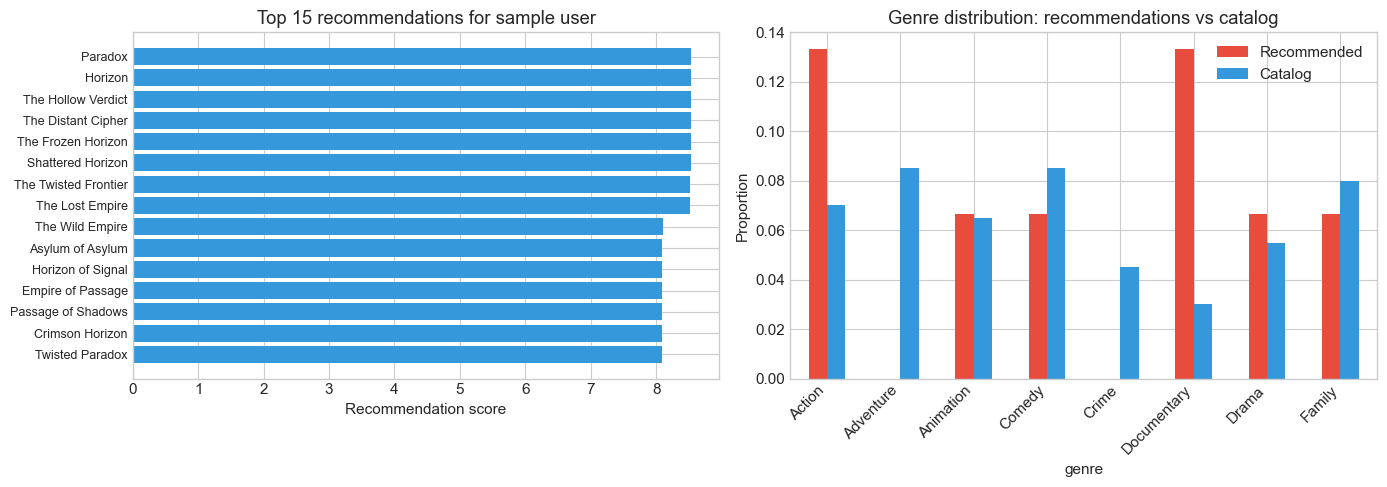

In [22]:
# Visualize: recommendation score distribution for one user
sample_user = df_users.iloc[0]['user_id']
recs = recommend_content(sample_user, n_recommendations=15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recommendation scores
axes[0].barh(range(len(recs)), recs['recommendation_score'], color='#3498db')
axes[0].set_yticks(range(len(recs)))
axes[0].set_yticklabels(recs['title'].str[:25], fontsize=9)
axes[0].set_xlabel('Recommendation score')
axes[0].set_title(f'Top 15 recommendations for sample user')
axes[0].invert_yaxis()

# Genre distribution of recommendations vs all content
genre_recs = recs['genre'].value_counts(normalize=True)
genre_all = df_content['genre'].value_counts(normalize=True)
compare = pd.DataFrame({'Recommended': genre_recs, 'Catalog': genre_all}).fillna(0).head(8)
compare.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#3498db'])
axes[1].set_title('Genre distribution: recommendations vs catalog')
axes[1].set_ylabel('Proportion')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

### 5.4 Content Recommendations — Key Takeaways

- **Collaborative filtering works** even with a modest dataset — similar users tend to enjoy similar content
- **Sparsity is the main challenge** — with 200 content items and 491 users, most users have watched a significant portion of the catalog
- **Hit rate** measures whether at least one held-out item appears in the top-N recommendations
- **Business Application:** Show "Users like you also watched..." carousels on the homepage, or send personalized weekly digests featuring recommended titles

---
## 6. Summary & Business Impact

### Three models, one warehouse

| Model | Technique | Key Metric | Business Use |
|-------|-----------|-----------|-------------|
| **Churn Prediction** | Logistic Regression + Random Forest | AUC-ROC | Target at-risk users with retention campaigns |
| **DAU Forecasting** | SARIMA time series | MAE / MAPE | Capacity planning + marketing scheduling |
| **Recommendations** | Collaborative filtering (cosine similarity) | Hit Rate @10 | Personalized content suggestions |

### Architecture

```
MySQL Data Warehouse (StreamDW)
    ├── mart_user_engagement  →  Churn Prediction (scikit-learn)
    ├── v_daily_active_users  →  DAU Forecasting (statsmodels)
    └── fact_viewing_events   →  Recommendations (scipy)
```

### What makes this portfolio-worthy

1. **End-to-end pipeline:** Raw data → SQL warehouse → Python ML → business insights
2. **Multiple model types:** Classification, time series, recommendation — three core ML families
3. **Business-driven:** Every model answers a real stakeholder question
4. **Production patterns:** Train/test splits, evaluation metrics, feature importance
5. **Warehouse integration:** Models read directly from the SQL reporting layer, not flat files

In [23]:
# Close the database connection
conn.close()
print("Database connection closed. Notebook complete!")

Database connection closed. Notebook complete!
